<a href="https://colab.research.google.com/github/hector1994/-IIB415A-2-2026-1-1-1500C_BUSINESS-INTELLIGENCE/blob/main/Class_2_Business_Intelligence_Students_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###📚  __Main imports__

In [ ]:
#LIBRERÍAS PRINCIPALES
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

###🛠️ __Reading Data: CSV file - Transactional data__

In [ ]:
#LEER DATAFRAME Y EXPLORAR PRIMEROS/ÚLTIMOS REGISTROS
path = "/content/drive/MyDrive/BI - Session 2/BI_Class_2_eda.csv" #RUTA DEL ARCHIVO, YA SEA EN SU PC O GOOGLE DRIVE (MODIFIQUE PARA SU CASO PARTICULAR)

#EN CASO DE SER INCAPAZ DE CONECTARSE DESDE GOOGLE-DRIVE, FAVOR USAR LA SIGUIENTE RUTA.
path_alternative = "https://raw.githubusercontent.com/hector1994/-IIB415A-2-2026-1-1-1500C_BUSINESS-INTELLIGENCE/refs/heads/main/BI_Class_2_eda.csv"
df  = pd.read_csv(path)                                                        #GENERANDO DATAFRAME.
#df = pd.read_csv(path_alternative)                                            #GENERANDO DATAFRAME.

df.head()   #df.tail()                                            #VISUALIZAR LOS PRIMEROS/ÚLTIMOS N REGISTROS

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,united states,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,Clothing,Canada,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394


###🗺️ __Exploratoy Data Analysis (EDA)__

####✅ __Let's check the dataframe features__

In [ ]:
#MÉTODO describe(): RESUMEN ESTADÍSTICO INSTANTANEO SOBRE LAS COLUMNAS NUMÉRICAS (INT, FLOAT) DEL DATAFRAME.
df.describe()

,Transaction_ID,Customer_Age,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
count,2550.000000,2424.000000,2550.000000,2550.000000,2550.000000,2475.000000,2550.000000
mean,6225.480392,49.094884,5.545882,315.166411,52.028912,3.049203,1411.328312
std,734.631632,17.877030,2.882295,702.822872,27.756064,1.000743,1153.869290
min,5000.000000,18.000000,1.000000,10.005701,5.114343,1.000000,-10.294671
25%,5587.250000,34.000000,3.000000,132.373066,27.511696,2.266439,448.038896
50%,6224.500000,49.000000,6.000000,258.960575,51.324563,3.032429,1086.333938
75%,6861.750000,65.000000,8.000000,379.875368,76.712596,3.835179,2105.937489
max,7499.000000,79.000000,10.000000,11478.781639,99.890259,5.000000,4992.820153


In [ ]:
#MÉTODO info(): RESUMEN GENERAL DEL DATAFRAME - NOMBRE COLUMNA, CANTIDAD DE REGISTROS NO NULOS Y TIPO DE DATO.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    2550 non-null   int64  
 1   Date              2550 non-null   object 
 2   Customer_Age      2424 non-null   float64
 3   Product_Category  2550 non-null   object 
 4   Country           2550 non-null   object 
 5   Units_Sold        2550 non-null   int64  
 6   Unit_Price        2550 non-null   float64
 7   Shipping_Cost     2550 non-null   float64
 8   Rating            2475 non-null   float64
 9   Total_Revenue     2550 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 199.3+ KB


In [ ]:
#columns - ATRIBUTO: LISTA DE LAS COLUMNAS DEL DATAFRAME.
df.columns

Index(['Transaction_ID', 'Date', 'Customer_Age', 'Product_Category', 'Country',
       'Units_Sold', 'Unit_Price', 'Shipping_Cost', 'Rating', 'Total_Revenue'],
      dtype='object')

In [ ]:
#DATAFRAME shape - ATRIBUTO: ROWS - COLUMNS - DIMENSIONES DEL DATAFRAME.
df.shape

(2550, 10)

####🔢 __Let's apply some counting to our categorical features__

In [ ]:
#SELECCIONAR UN SUBCONJUNTO > 1 DE COLUMNAS DEL DATAFRAME Y VISUALIZAR DICHAS COLUMNAS.
column_list = [ 'Date','Transaction_ID', 'Customer_Age', 'Product_Category'] #Columnas de interés
df[column_list]

,Date,Transaction_ID,Customer_Age,Product_Category
0,2024-01-01 00:00:00,5000,56.0,Clothing
1,2024-01-01 01:00:00,5001,69.0,Clothing
2,2024-01-01 02:00:00,5002,46.0,Home
3,2024-01-01 03:00:00,5003,32.0,Clothing
4,2024-01-01 04:00:00,5004,60.0,Toys
...,...,...,...,...
2545,2024-01-02 21:00:00,5045,79.0,Electronic
2546,2024-01-02 22:00:00,5046,79.0,Clothing
2547,2024-01-02 23:00:00,5047,64.0,Home
2548,2024-01-03 00:00:00,5048,79.0,Clothing


In [ ]:
#MÉTODO value_counts(): CONTEO DE REGISTROS ASOCIADOS A UNA VARIABLE CATEGÓRICA (NOMINAL-ORDINAL)
100*df['Country'].value_counts(normalize= True)

,proportion
Country,
UK,15.568627
Canada,14.862745
U.S.A.,13.372549
united states,12.823529
USA,12.352941
usa,11.960784
France,9.568627
Germany,9.490196


In [ ]:
#MÉTODO unique(): VALORES DISTINTOS EN COLUMNA CATEGÓRICA
df['Product_Category'].unique()

array(['Clothing', 'Home', 'Toys', ' Elect. ', 'Books', 'Electronic',
       'ELECTRONICS', 'electronics'], dtype=object)

In [ ]:
#MÉTODO nunique(): CANTIDAD DE VALORES DISTINTOS EN UNA COLUMNA CATEGÓRICA.
df['Country'].nunique()

8

###🧐 __Analyzing + Solving Data issues__

* __Nan Values__
* __Standarize categorical features__
* __Duplicated rows__


In [ ]:
#Método insa() y sum(): NaN Summary: CONTAR VALORES FALTANTES POR CADA FEATURE DEL DATAFRAME (NUMÉRICOS Y CATEGÓRICOS)
df.isna().sum()

,0
Transaction_ID,0
Date,0
Customer_Age,126
Product_Category,0
Country,0
Units_Sold,0
Unit_Price,0
Shipping_Cost,0
Rating,75
Total_Revenue,0


In [ ]:
#ESTADÍSTICOS DE TENDECIA CENTRAL, DISPERSIÓN Y POSICIÓN (COLUMNAS NUMÉRICAS)
age_mean   = df['Customer_Age'].mean()
age_median = df['Customer_Age'].median()

In [ ]:
age_median

49.0

In [ ]:
#FILLNA: LUEGO DE DECIDIR COMO IMPUTAR (RELLENAR VALORES FALTANTES), APLICAR PROCESO DE RELLENADO.
df['Customer_Age'] = df['Customer_Age'].fillna(age_mean)

In [ ]:
#Standarize Categorical Features
df['Country'].value_counts()

,count
Country,
UK,397
Canada,379
U.S.A.,341
united states,327
USA,315
usa,305
France,244
Germany,242


In [ ]:
#STANDARIZING: QUITAR ESPACIOS, REEMPLAZAR CARÁCTERES RAROS, DEFINIR FORMATO: MAYÚSCULAS, MINUSCULAS, NOMBRE PROPIO.
df['Country'] = df['Country'].str.strip() #ELIMINAR ESPACIOS EN BLANCO
df['Country'] = df['Country'].replace(".","") #QUITAR PUNTOS ---> FIND AND REPLACE
df['Country'] = df['Country'].str.upper()  #PASAR TODO A MAYUSCULA: UPPER(), LOWER(), TITLE()

In [ ]:
df['Country'].value_counts()

,count
Country,
USA,620
UK,397
CANADA,379
U.S.A.,341
UNITED STATES,327
FRANCE,244
GERMANY,242


In [ ]:
#DUPLICATED VALUES: TOTAL REGISTROS DUPLICADOS.
df.duplicated().sum()

np.int64(50)

In [ ]:
#VER REGISTROS DUPLICADOS.
#keep = 'first': Muestra primer duplicado encontrado (por pares), es decir si un registro está dos veces, muestra solo el primero de este par.
#keep = 'last' : Muestra último duplicado encontrado (por pares), es decir si un registro está dos veces, muestra solo el último de este par.
#keep = 'False': Muestra ambos registros por pares, es decir, muestra literalmente los registros copiados, todos (preferible si queiren ver estos duplicados)
df[df.duplicated(keep = False)]

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,Clothing,CANADA,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394
...,...,...,...,...,...,...,...,...,...,...
2545,5045,2024-01-02 21:00:00,79.0,Electronic,UNITED STATES,8,107.775801,71.770828,2.221011,840.051185
2546,5046,2024-01-02 22:00:00,79.0,Clothing,U.S.A.,6,343.311839,63.334143,2.138245,2042.413167
2547,5047,2024-01-02 23:00:00,64.0,Home,CANADA,1,45.377220,53.474951,1.914145,72.851555
2548,5048,2024-01-03 00:00:00,79.0,Clothing,USA,5,25.019726,46.209518,2.195353,114.099654


In [ ]:
#VER REGISTROS DUPLICADOS, PERO ORDENADOS USANDO df.sort_values(by = 'columna de ordenamiento', ascending = True/False) - ASÍ DE VEN JUNTOS ESTOS DUPLICADOS, PERMITE VERLOS MEJOR.
df[df.duplicated(keep = False)].sort_values(by = 'Transaction_ID', ascending = True)

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
2500,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
2501,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,UNITED STATES,1,347.837835,21.641612,3.171993,337.542782
...,...,...,...,...,...,...,...,...,...,...
2547,5047,2024-01-02 23:00:00,64.0,Home,CANADA,1,45.377220,53.474951,1.914145,72.851555
2548,5048,2024-01-03 00:00:00,79.0,Clothing,USA,5,25.019726,46.209518,2.195353,114.099654
48,5048,2024-01-03 00:00:00,79.0,Clothing,USA,5,25.019726,46.209518,2.195353,114.099654
49,5049,2024-01-03 01:00:00,68.0,Clothing,CANADA,8,136.264615,61.360754,2.798174,1080.069873


In [ ]:
#DELETING DUPLICATES: BORREMOS LOS DUPLICADOS
#keep = 'first': ELIMINAR DUPLICADOS CONSERVANDO UNO DE ESTAS COPIAS, EN ESTE CASO EL PRIMERO ENCONTRADO POR PANDAS (ESCANEANDO DE ARRIBA A ABAJO).
#keep = 'last' : ELIMINAR DUPLICADOS CONSERVANDO UNO DE ESTAS COPIAS, EN ESTE CASO EL ÚLTIMO ENCONTRADO POR PANDAS  (ESCANEANDO DE ARRIBA A ABAJO).
#keep = 'False': BORRAR LOS DUPLICADOS NO DEJANDO RASTRO DE ESTAS COPIAS, NO SE CONSERVA NADA, ELIMINACIÓN ABSOLUTA.
df.drop_duplicates(keep = 'first', inplace = True)

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2495,False
2496,False
2497,False
2498,False


###📊 __Basic statiscal summary__

In [ ]:
#CREATE A SUMMARY FUNCTION: GENERAMOS UNA FUNCIÓN QUE RECIBA COMO ENTRADA UN DATAFRAME, QUE GENERE UN ANÁLISIS ESTADÍSITICO COMPLETO.
#DEFINAMOS UNA FUNCIÓN QUE PERMITA CALCULAR TODA LA ESTADÍSTICA DESCRIPTIVA BÁSICA PARA LAS COLUMNAS NUMÉRICAS.

#INPUT_1: DATAFRAME A ANALIZAR.
#INPUT_2: LISTA DE COLUMNAS NUMÉRICAS QUE SE QUIEREN RESUMIR ESTADÍSTICAMENTE (PUEDEN SER TODAS LAS COLUMNAS NUMÉRICAS O UN SUBCONJUNTO DE ESTAS.)


def statistic_numerical_variables(data,num_column_list):

  print("RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:")
  print("-----------------------------------")

  for column in num_column_list:
  #PUEDEN AÑADIR CUALQUIER CÁLCULO ADICIONAL: POR EJEMPLO: DECILES, QUINTILES, PERCENTILES, VARIANZA, COEFICIENTE DE VARIACIÓN
    min     = data[column].min()
    max     = data[column].max()
    range   = (data[column].max() - data[column].min())
    mean    = data[column].mean()
    median  = data[column].median()
    std     = data[column].std()
    var     = data[column].var()
    Q1      = data[column].quantile(0.25)
    Q2      = data[column].quantile(0.50)
    Q3      = data[column].quantile(0.75)
    IQR     = Q3 - Q1                            #RANGO INTERCUARTÍLICO.

    print(f"REPORTE COLUMNA: {column}")
    print(f"- min              : {min}")
    print(f"- max              : {max}")
    print(f"- range            : {range}")
    print(f"- mean             : {mean}")
    print(f"- median           : {median}")
    print(f"- standar deviation: {std}")
    print(f"- variance         : {var}")
    print(f"- Q1 (25%)         : {Q1}")
    print(f"- Q2 (50%)         : {Q2}")
    print(f"- Q3 (75%)         : {Q3}")
    print(f"- IQR              : {IQR}")
    print(f"-----------------------------------")

In [ ]:
#AUTOMATIC VARIABLE TYPE DETECTION: LOS SIGUIENTES MÉTODOS PERMITEN DETECTAR EL TIPO DE DATO DE CADA FEATURE DE FORMA
#                                   AUTOMÁTICA. ES ÚTIL PARA SERPAR LO CUANTITATIVO DE LO CUALITATIVO DE FORMA RÁPIDA.

df_numerico = df.select_dtypes(include=['number']).columns #DATAFRAME QUE CONTIENE SOLO COLUMNAS NUMÉRICAS: FLOAT, INT
df_texto    = df.select_dtypes(include=['object']).columns #DATAFRAME QUE CONTIENE SOLO COLUMNAS CATEGÓRICAS: object (string-text)

In [ ]:
statistic_numerical_variables(data = df, num_column_list = df_numerico)

RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:
-----------------------------------
REPORTE COLUMNA: Transaction_ID
- min              : 5000
- max              : 7499
- range            : 2499
- mean             : 6249.5
- median           : 6249.5
- standar deviation: 721.8321596234589
- variance         : 521041.6666666667
- Q1 (25%)         : 5624.75
- Q2 (50%)         : 6249.5
- Q3 (75%)         : 6874.25
- IQR              : 1249.5
-----------------------------------
REPORTE COLUMNA: Customer_Age
- min              : 18.0
- max              : 79.0
- range            : 61.0
- mean             : 49.04474422442244
- median           : 49.09488448844885
- standar deviation: 17.407482767195365
- variance         : 303.0204562902036
- Q1 (25%)         : 35.0
- Q2 (50%)         : 49.09488448844885
- Q3 (75%)         : 64.0
- IQR              : 29.0
-----------------------------------
REPORTE COLUMNA: Units_Sold
- min              : 1
- max              : 10
- range            : 9
- mean    

In [ ]:
def cleaning_dataframe(data, numeric_cols, categorical_cols):
    # Limpieza de numéricos
    for column in numeric_cols:
        column_mean = data[column].mean()
        data[column] = data[column].fillna(column_mean)

    for column in categorical_cols:
        data[column] = data[column].str.strip().str.upper()

        # --- NUEVA SECCIÓN DE UNIFICACIÓN ---
        # Creamos un diccionario para mapear nombres repetidos
        mapeo_paises = {
            "USA": "UNITED STATES",
            "U.S.A.": "UNITED STATES",
            "UK": "UNITED KINGDOM",
            "ELECT": "ELECTRONICS",
            "ELECTRONIC": "ELECTRONICS"
        }
        # Usamos replace en la columna para unificar
        data[column] = data[column].replace(mapeo_paises)
        # ------------------------------------

        data[column] = data[column].fillna("UNKNOWN")

    data.drop_duplicates(inplace=True)
    return data


In [ ]:
df_clean = cleaning_dataframe(data = df, numeric_cols = df_numerico , categorical_cols = df_texto)

In [ ]:
#VERIFIQUEMOS: VALORES NULOS
df_clean.isna().sum()

,0
Transaction_ID,0
Date,0
Customer_Age,0
Product_Category,0
Country,0
Units_Sold,0
Unit_Price,0
Shipping_Cost,0
Rating,0
Total_Revenue,0


In [ ]:
#VERIFICACIÓN: INCONSISTENCIAS EN COLUMNAS CATEGÓRICAS.
df_clean['Country'].value_counts()

,count
Country,
UNITED STATES,1267
UNITED KINGDOM,386
CANADA,368
FRANCE,242
GERMANY,237


In [ ]:
#VERIFICACIÓN: INCONSISTENCIAS EN COLUMNAS CATEGÓRICAS.
df_clean['Product_Category'].value_counts()

,count
Product_Category,
CLOTHING,518
BOOKS,505
TOYS,476
HOME,472
ELECTRONICS,376
ELECT.,153


In [ ]:
#CONTEMOS DUPLICADOS
df_clean.duplicated().sum()

np.int64(0)

###📈 __Let's plot some results__: SEABORN + MATPLOTLIB

* __Seaborn__ is a Python data visualization library built on top of Matplotlib that offers a sophisticated interface for generating high-level statistical graphics. It provides an extensive range of professionally styled themes and color palettes, streamlining the creation of complex visualizations with minimal code.

* __Matplotlib__ serves as the foundational, low-level engine for plotting in Python. While more traditional, its integration with Seaborn is essential, as it grants granular control over the figure's structural elements. By leveraging Matplotlib’s API, users can programmatically manage core components such as figure titles, axis labels, legends, and the rendering of supplementary geometric primitives or annotations over the primary plot.

In [ ]:
df_clean.columns

Index(['Transaction_ID', 'Date', 'Customer_Age', 'Product_Category', 'Country',
       'Units_Sold', 'Unit_Price', 'Shipping_Cost', 'Rating', 'Total_Revenue'],
      dtype='object')

####📊 __Barplot__

/tmp/ipykernel_218/1311426317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_clean,                              #DATAFRAME.


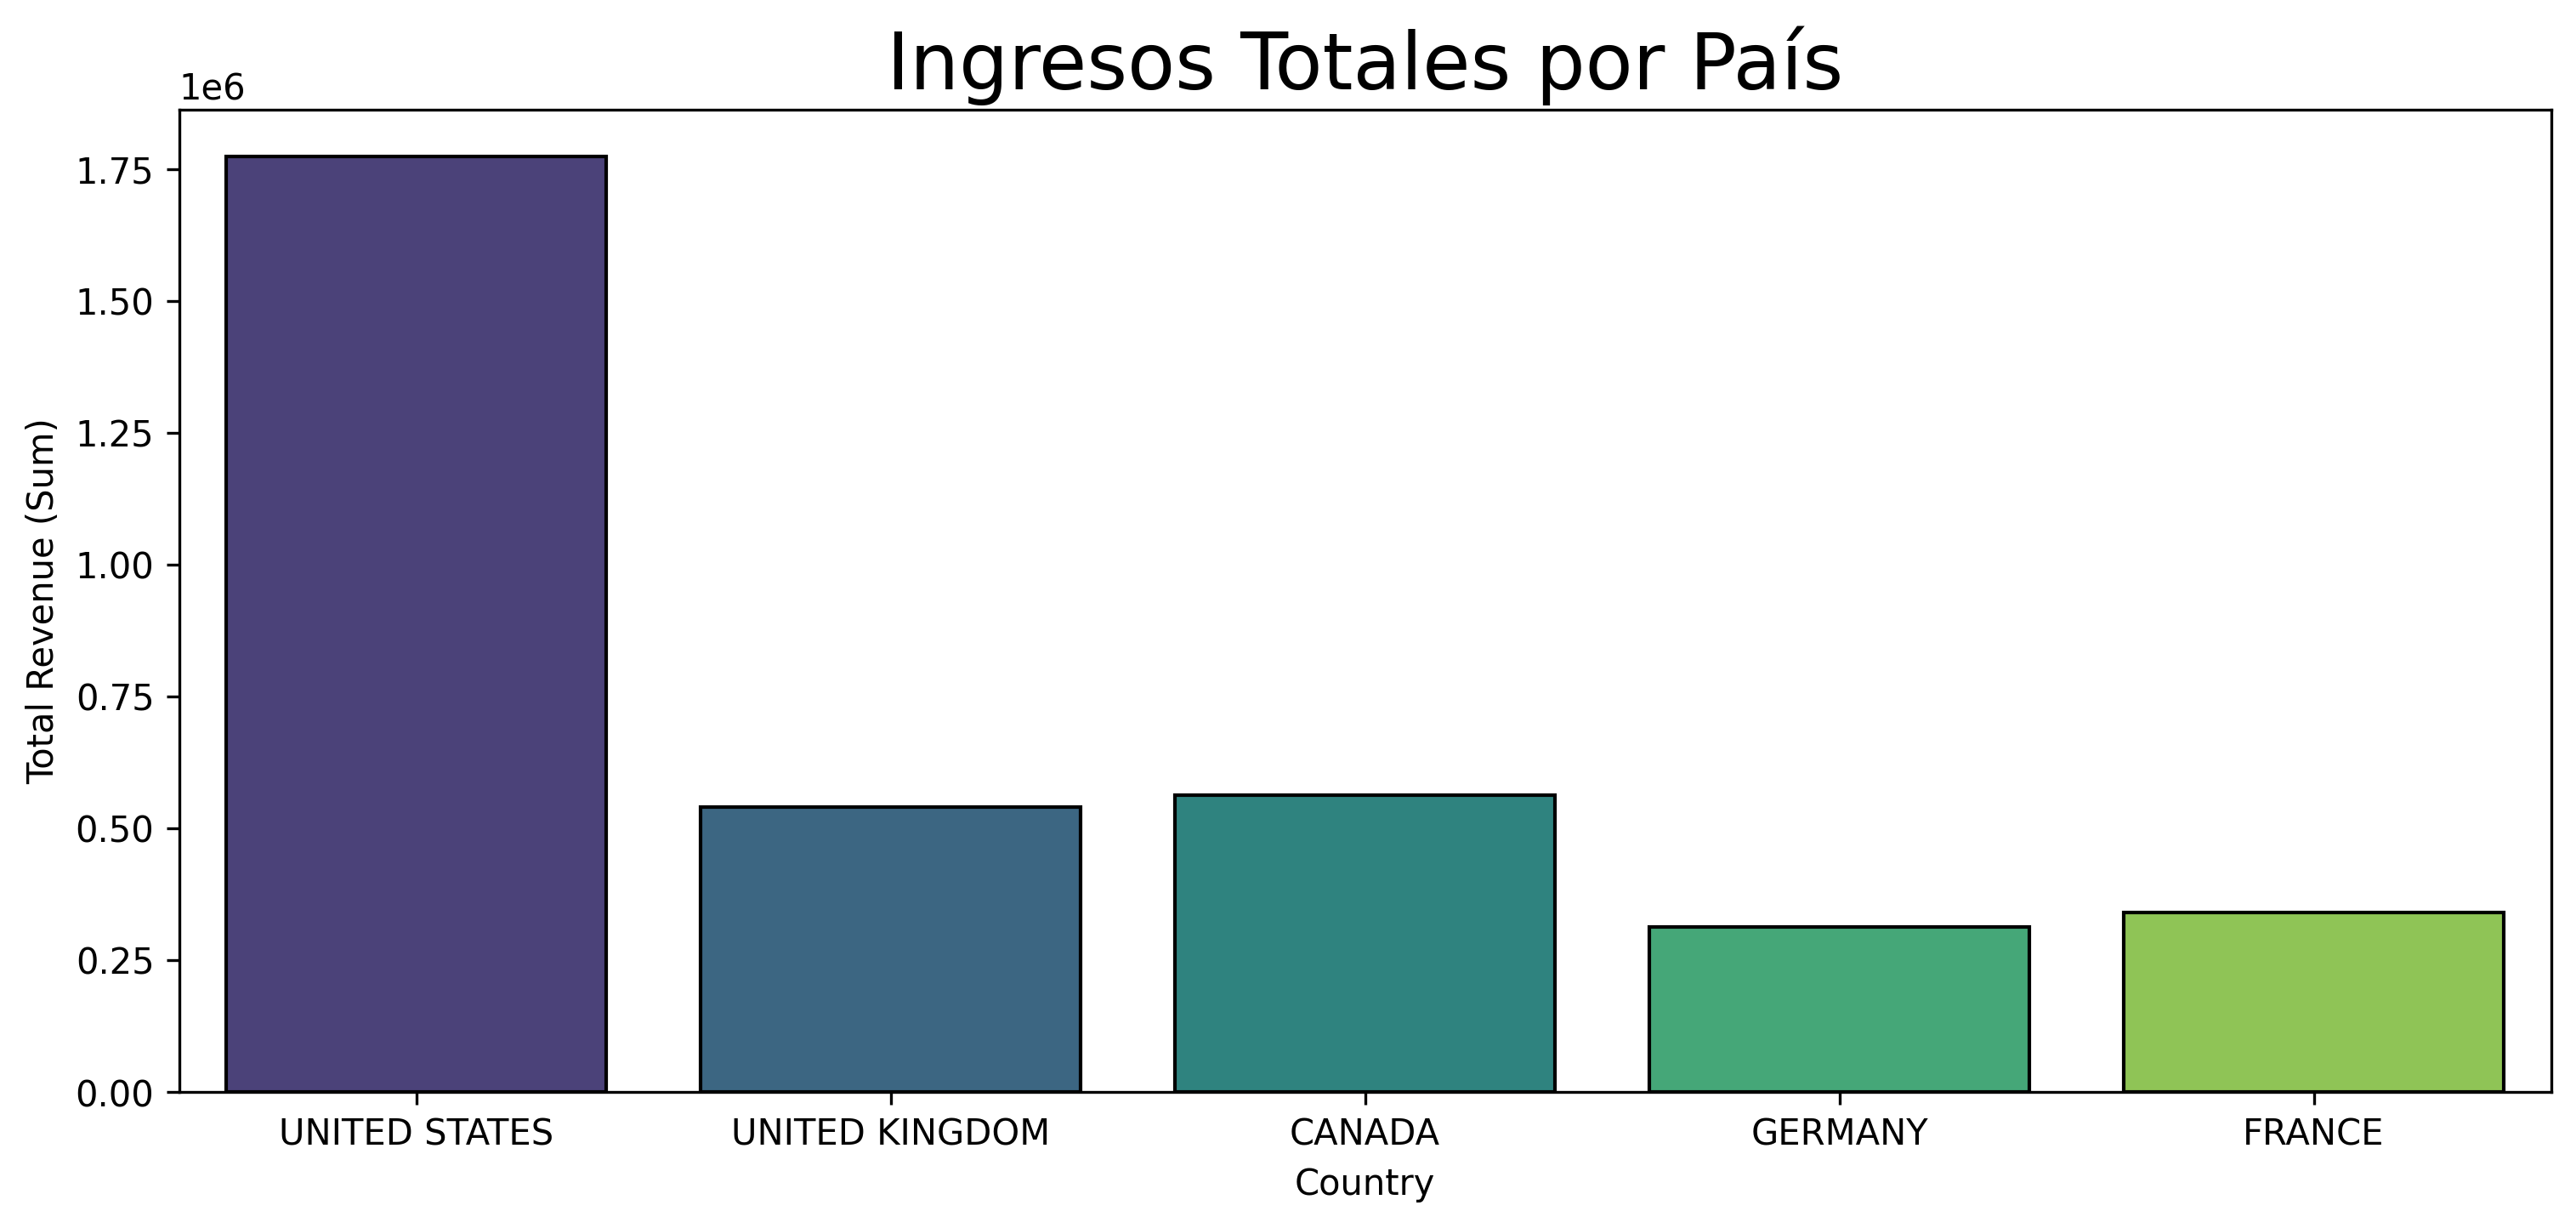

In [ ]:
plt.figure(figsize=(12,5),dpi=300) #DEFINE DIMENSIONES DE LA GRÁFICA CON MATPLOTLIB
#LLAMAMOS DE LA LIBRERÍA SEABORN EL GRÁFICO DE BARPLOT.
sns.barplot(data = df_clean,                              #DATAFRAME.
            x = 'Country',                                #COLUMNA CATEGÓRICA.
            y = 'Total_Revenue',                          #COLUMNA NUMÉRICA.
            estimator = "sum",                            #ALTURA DE LA BARRA (CÁCULOS COMO: SUM, MEAN, MAX, MIN, STD, ETC.)
            palette = 'viridis',                          #PALETA DE COLORES, EXISTEN MUCHAS.
            edgecolor = "black",                          #COLOR DEL BORDE LA BARRA.
            errorbar = None)                              #ELIMINAR BARRA DE ERRORES, SON MOLESTAS A VECES, PERO SI FIJAN VALOR TRUE, PUEDEN VERLAS (MUY  COMÚN EN EXCEL)

plt.title('Ingresos Totales por País', fontsize = 22)     #DEFINIMOS TÍTULO.
plt.xlabel("Country")                                     #NOMBRE EJE HORIZONTAL.
plt.ylabel('Total Revenue (Sum)')                         #NOMBRE EJE VERTICAL
plt.show()                                                #MOSTRAR GRÁFICO. SI NO SE PONE ESTA SENTENCIA AL FINAL, EL GRÁFICO SE CREA COMO OBJETO, PERO NO SALE VISUALIZADO POR PANTALLA.

#### 🚀__Histogram__


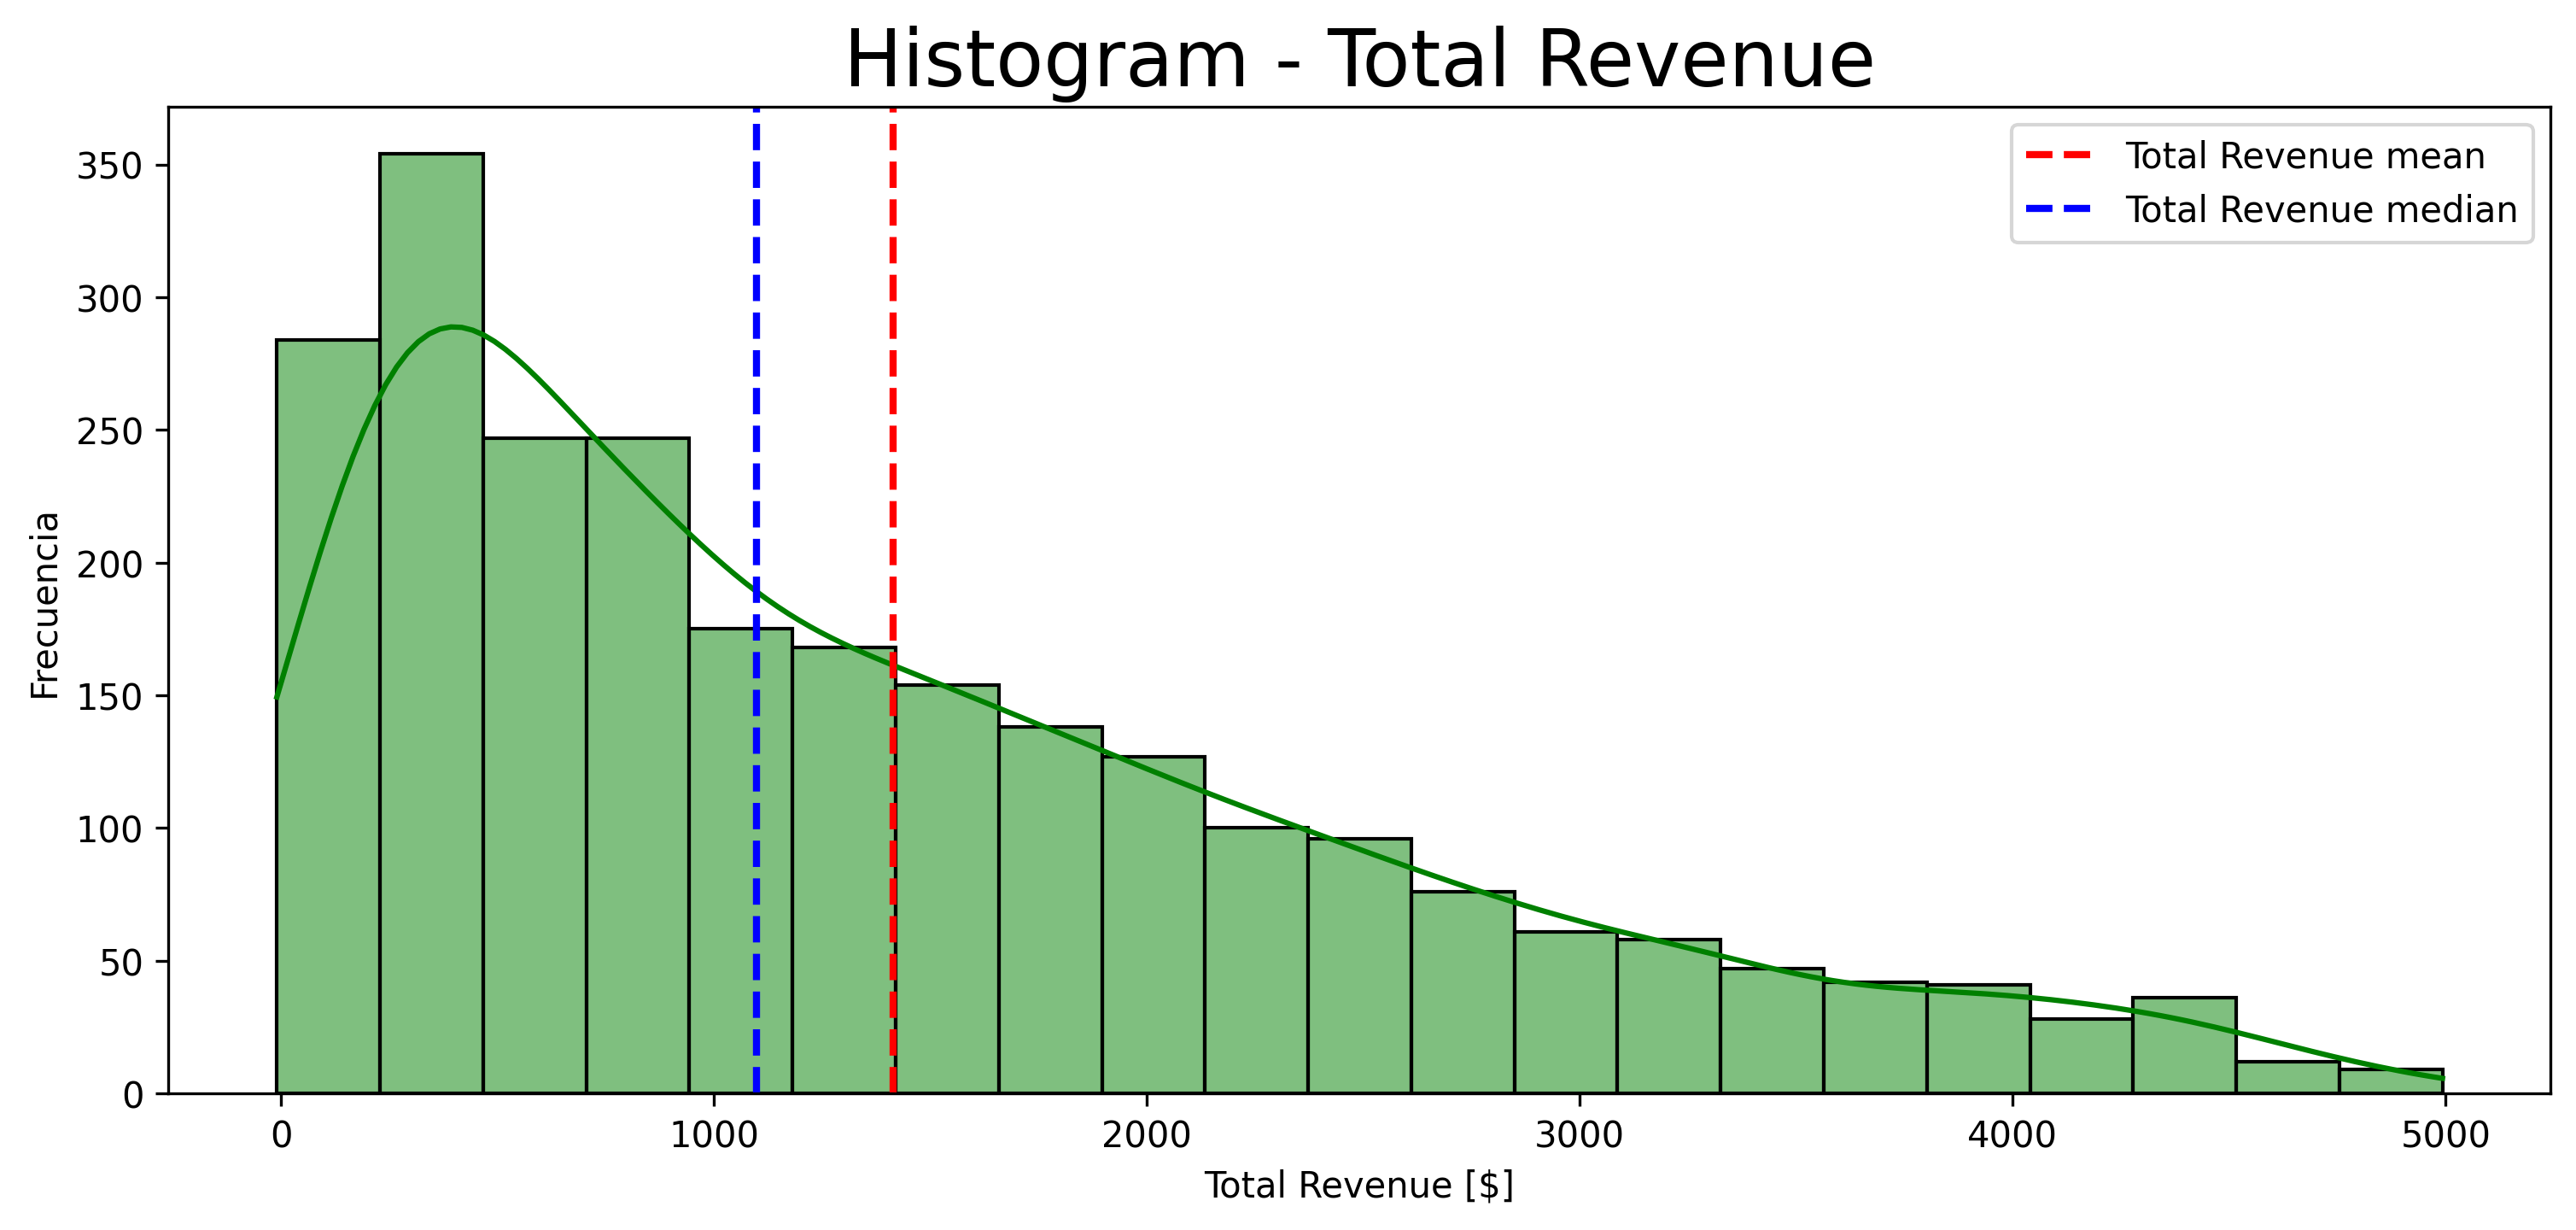

In [ ]:
#CALCULEMOS LA MEDIA Y MEDIANA PARA LA VARIABLE NUMÉRICA QUE QUEREMOS GRAFICAR CON UN HISTOGRAMA. EL OBJETIVO, ES PODER INCLUIR,
#RECTAS VERTICALES QUE MUESTREN ESTOS VALORES DENTRO DEL RANGO DE LA VARIABLE.
mean   = df_clean['Total_Revenue'].mean()
median = df_clean['Total_Revenue'].median()

plt.figure(figsize=(12,5),dpi=300)

sns.histplot(data = df_clean,             #DATASET
             x = 'Total_Revenue',         #VARIABLE NUMÉRICA
             color = "green",             #COLOR BARRA
             kde= True)                   #CURVA DE DENSIDAD QUE MUESTRA EL PERFIL-FORMA DE LA DISTRIBUCIÓN CON UNA LINEA CURVA

plt.axvline(x = mean, color ='red' , linestyle ="--" , linewidth = 2, label = "Total Revenue mean" )       #LÍNEA VERTICAL MEDIA.
plt.axvline(x = median, color ='blue' , linestyle ="--" , linewidth = 2, label = "Total Revenue median" )  #LÍNEA VERTICAL MEDIANA

plt.legend() #MOSTRAR LEYENDAS DEFINIDAS EN label.
plt.title("Histogram - Total Revenue", fontsize = 22) #TÍTULO
plt.xlabel("Total Revenue [$]") #TITULO EJE X
plt.ylabel("Frecuencia") #TÍTULO EJE Y
plt.show()

####📦⚞ • ⚟ __Box plot__

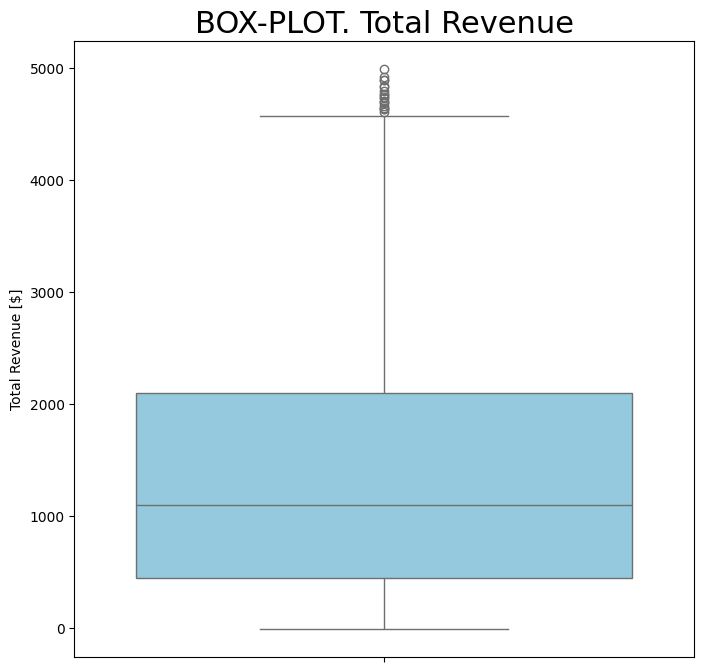

In [ ]:
plt.figure(figsize = (8,8),dpi=100) #DIMENSIONES FIGURA

sns.boxplot(data  = df_clean,        #DATAFRAME
            y     = "Total_Revenue", #COLUMNA NUMÉRICA - SETEAR X=.. SI SE QUIERE HORIZONTAL
            color = "skyblue")       #COLOR - TEMA

plt.title("BOX-PLOT. Total Revenue", fontsize = 22) #TÍTULO
plt.ylabel("Total Revenue [$]") #TÍTULO EJE Y.
plt.show()

####🌡️ __Heat map__: Correlation Matrix - Pearson coeficient

In [ ]:
corr = df_clean.corr(numeric_only=True)
corr

,Transaction_ID,Customer_Age,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
Transaction_ID,1.000000,-0.031783,-0.013755,0.013482,0.020508,0.021555,-0.024859
Customer_Age,-0.031783,1.000000,0.032862,-0.023720,0.017512,-0.833785,0.011821
Units_Sold,-0.013755,0.032862,1.000000,-0.004256,-0.001671,-0.053532,0.639262
Unit_Price,0.013482,-0.023720,-0.004256,1.000000,0.031147,-0.001817,0.170407
Shipping_Cost,0.020508,0.017512,-0.001671,0.031147,1.000000,0.002090,0.012409
Rating,0.021555,-0.833785,-0.053532,-0.001817,0.002090,1.000000,-0.031068
Total_Revenue,-0.024859,0.011821,0.639262,0.170407,0.012409,-0.031068,1.000000


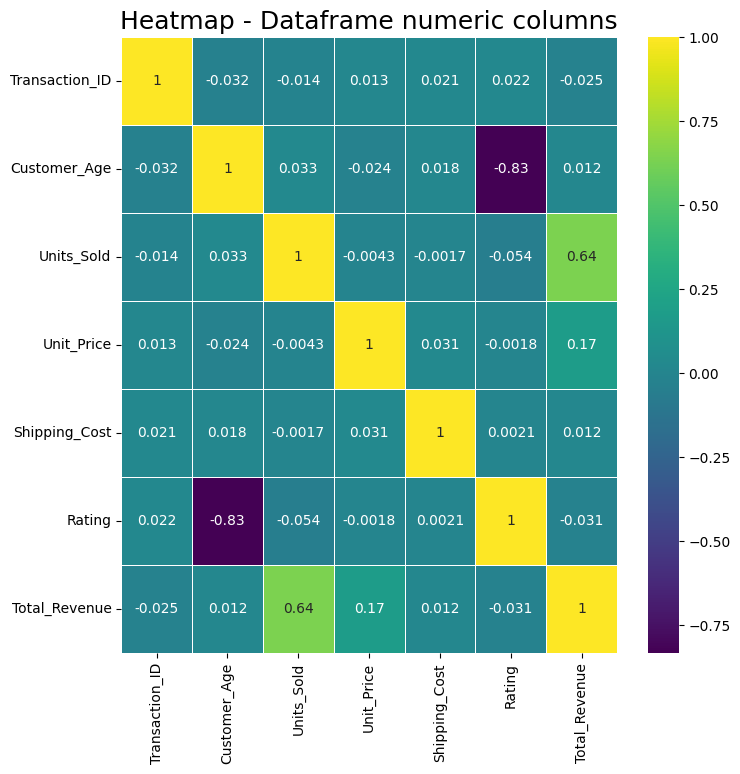

In [ ]:
plt.figure(figsize=(8,8),dpi=100)
sns.heatmap(corr,
            annot=True,       # Muestra los números dentro de los cuadros
            cmap='viridis',  # Color azul (frio) para negativo, rojo (calor) para positivo
            linewidths=0.5,   # Espacio entre celdas
            linecolor='white') # Color de la línea (equivalente a edgecolor)

plt.title("Heatmap - Dataframe numeric columns", fontsize = 18) #TÍTULO
plt.show()

####💥 __Scatter-plot__

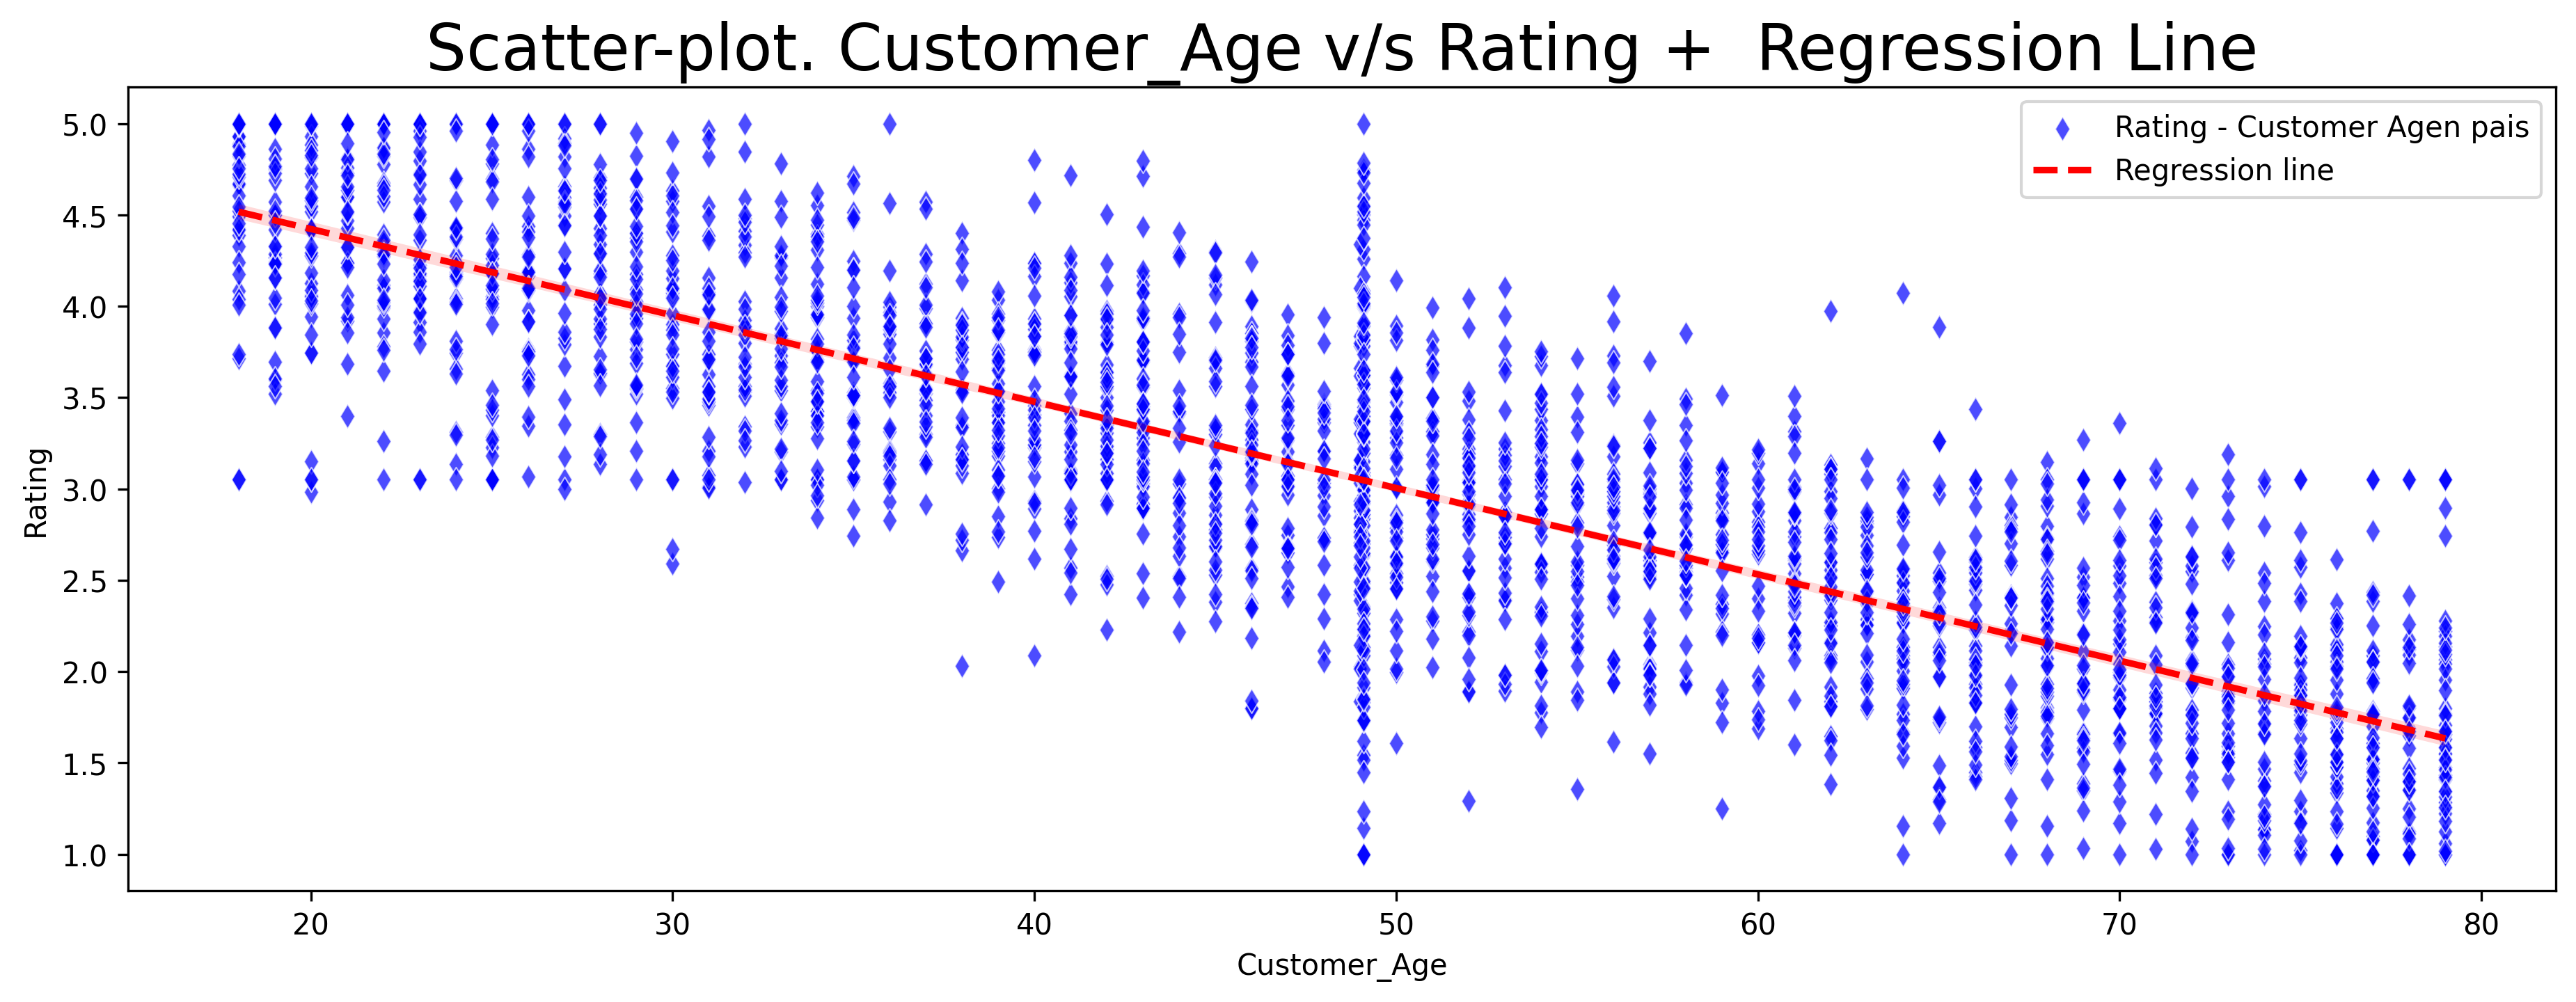

In [ ]:
plt.figure(figsize = (15,5), dpi=300)

sns.scatterplot(data=df_clean,                           #DATFRAME.
                x="Customer_Age",                        #COLUMNA NUMÉRICA 1.
                y="Rating",                              #COLUMNA NUMÉRICA 2.
                color ="blue",                           #COLOR PUNTOS.
                label = "Rating - Customer Agen pais",   #ETIQUETA PARA LEYENDA.
                marker="d",                              #ESTILO DE PUNTOS.
                alpha=0.7)                               #TRANSPARENCIA.


#PLOTEAR LÍNEA DE REGRESIÓN.
sns.regplot(data=df_clean,                     #DATAFRAME.
            x="Customer_Age",                  #VARIABLE DEPENDIENTE.
            y="Rating",                        #VARIABLE INDEPENDIENTE.
            scatter=False,                     #ES INNECESARIO PLOTEAR NUEVAMENTE EL SCATTER PLOT.
            line_kws={"color": "red", "linestyle": "--"},  #CARACTERÍSTICAS DE LA LÍNEA (COLOR-ESTÍLO).
            label="Regression line")                       #ETIQUETA PARA LEYENDA.

plt.title("Scatter-plot. Customer_Age v/s Rating +  Regression Line", fontsize = 22) #TÍTUTLO
plt.legend()                                                                         #MOSTRAR LEYENDA --> NECESARIO.
plt.show()